In [219]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.datasets import fetch_california_housing

In [221]:
housing = fetch_california_housing(as_frame=True)

x = housing.data
y = housing.target

In [222]:
print(x.head)


<bound method NDFrame.head of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Lo

In [223]:
print(y.head)

<bound method NDFrame.head of 0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64>


In [224]:
scaler = StandardScaler().fit(x)
x_rescaled = scaler.transform(x)

In [225]:
from sklearn.model_selection import train_test_split

In [226]:
x_train, x_test, y_train, y_test = train_test_split(x_rescaled, y)

print(x_train.size, y_train.size)
print(x_test.size, y_test.size)

123840 15480
41280 5160


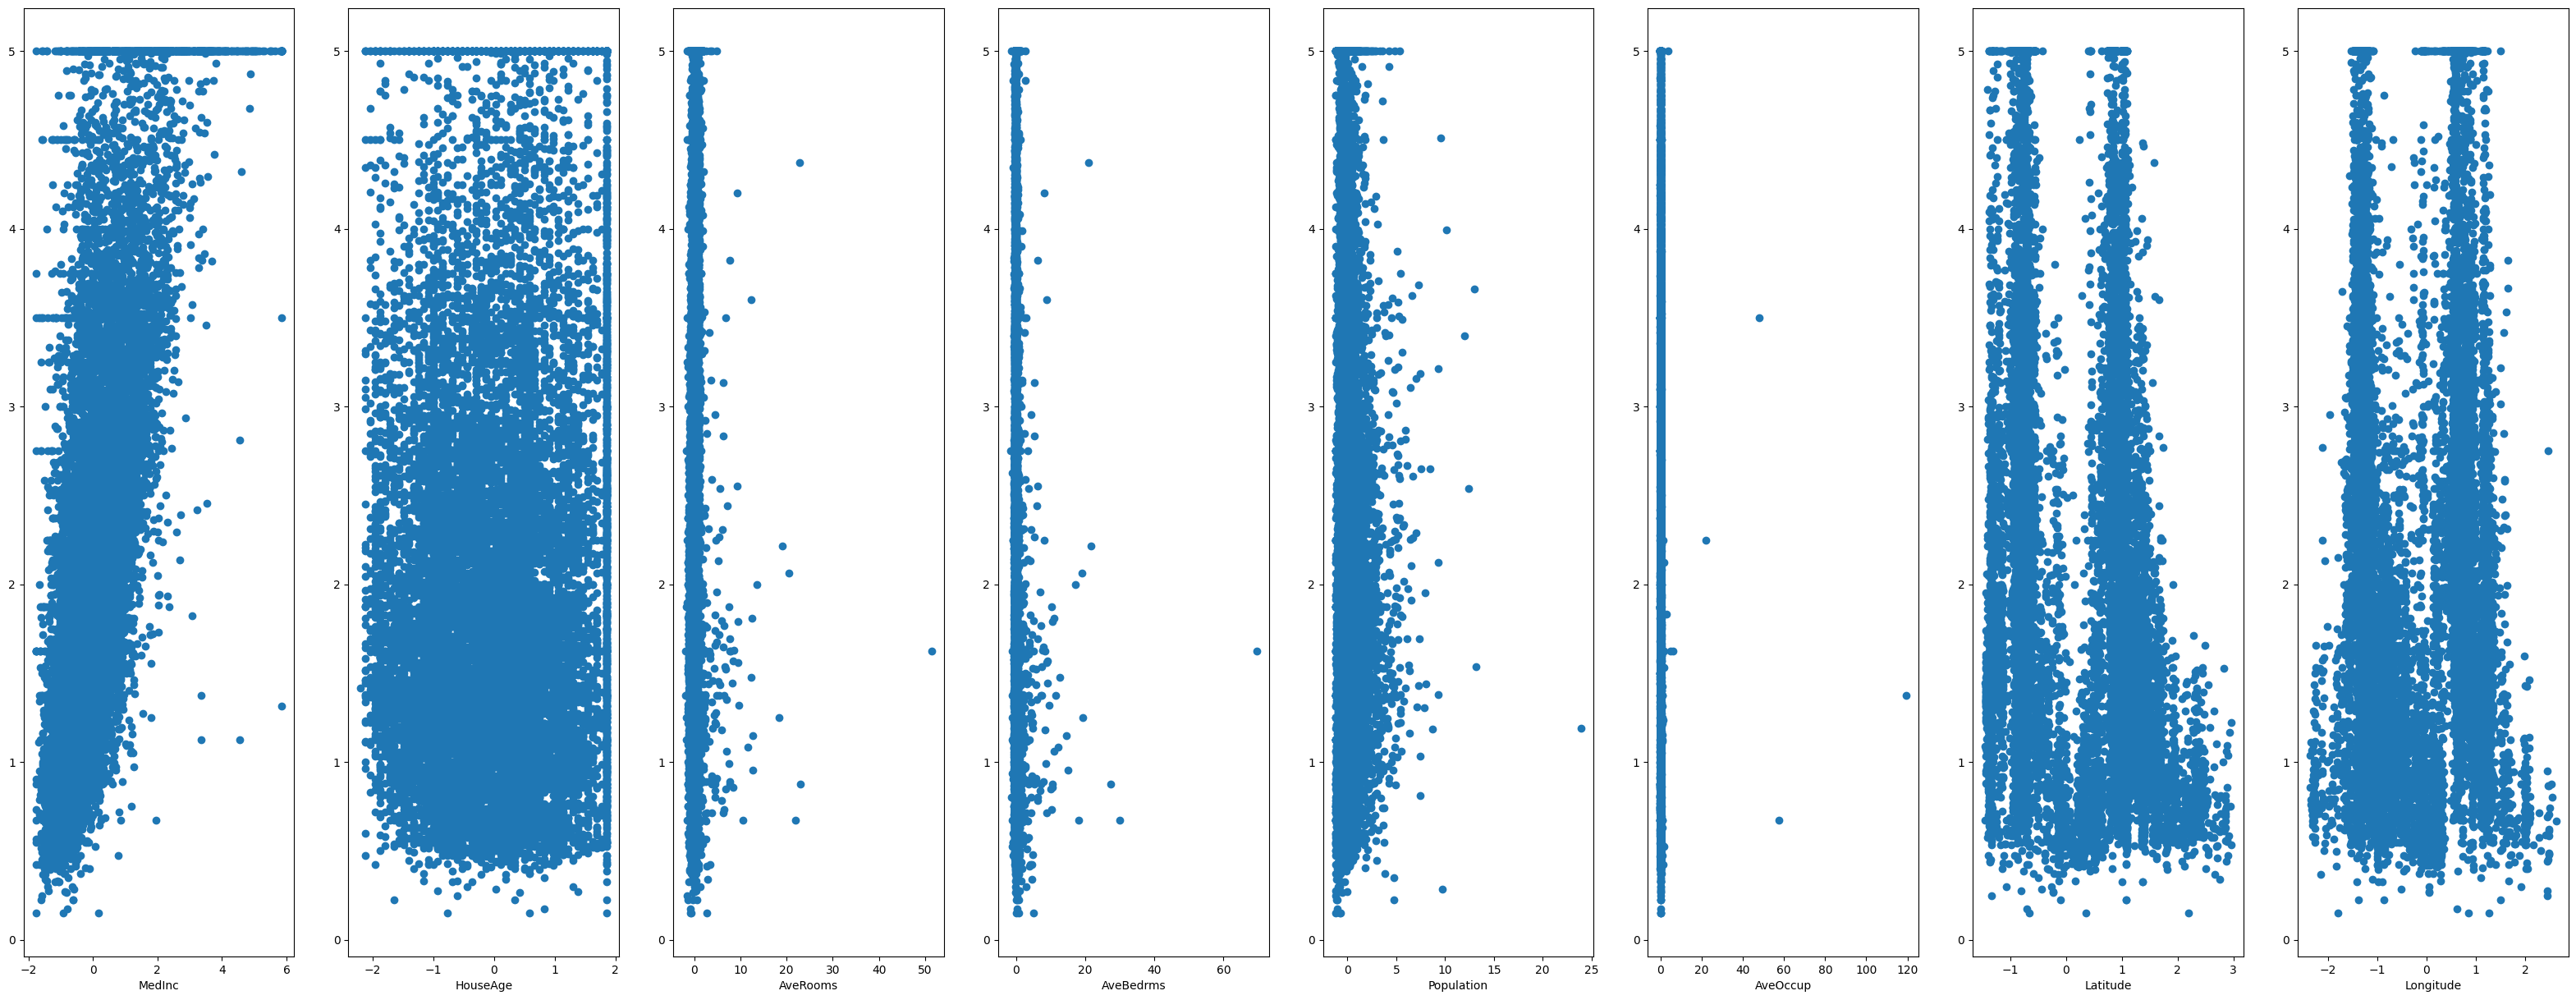

In [227]:
x_features = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude",
    "Longitude",
]

_, plot = plt.subplots(1,8, figsize=(40,15))

for i in range(len(plot)):
    plot[i].scatter(x_train[:, i], y_train, label = 'target')
    plot[i].set_xlabel(x_features[i])

In [228]:
regr = LinearRegression()
regr.fit(x_train, y_train)

print(regr.score(x_train, y_train))


0.6034423177458347


In [229]:
y_predic = regr.predict(x_test)

In [230]:
mse = mean_squared_error(y_test, y_predic)
mse

0.5045967011643028

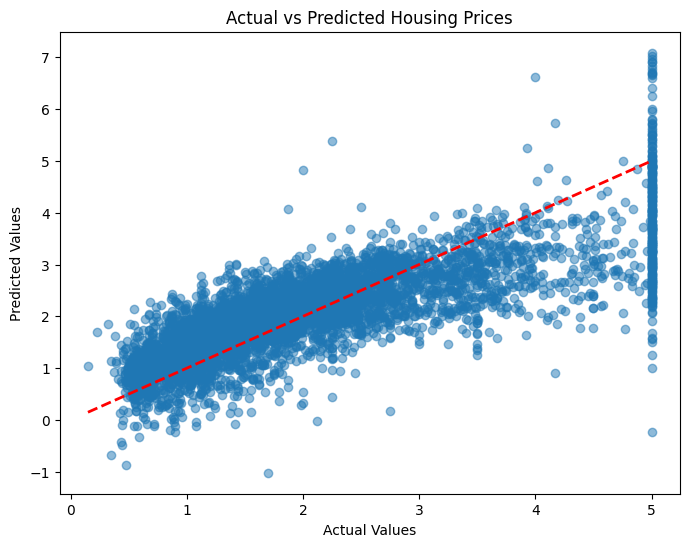

In [231]:
# Plot actual vs predicted (not vs a single feature)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predic, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

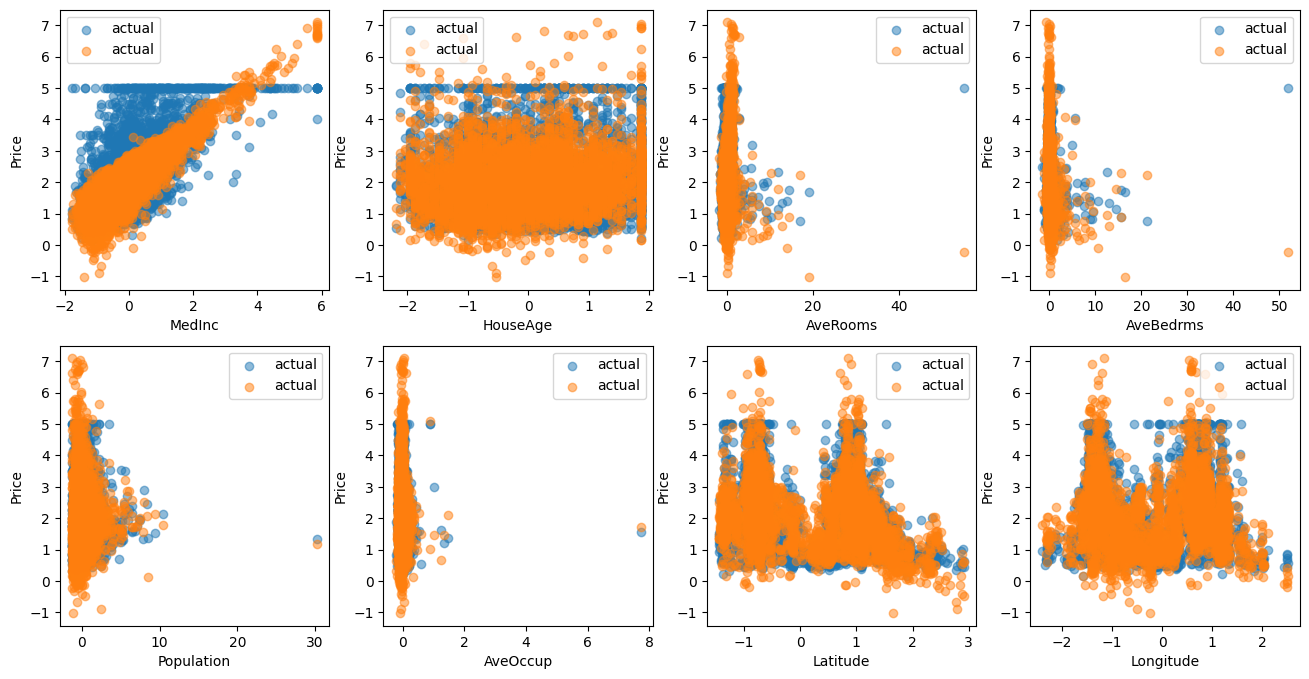

In [232]:
fig, plot = plt.subplots(2, 4, figsize=(16, 8))
plot = plot.ravel()

for i in range(8):
    plot[i].scatter(x_test[:, i], y_test, alpha=0.5, label="actual")
    plot[i].scatter(x_test[:, i], y_predic, alpha=0.5, label="actual")
    plot[i].set_xlabel(x_features[i])
    plot[i].set_ylabel('Price')
    plot[i].legend()

In [233]:
poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


In [234]:
regr_poly = LinearRegression()

regr_poly.fit(x_train_poly, y_train)
print(regr.score(x_train, y_train))
print(regr_poly.score(x_train_poly, y_train))

0.6034423177458347
0.6850533135598554


In [235]:
y_predic_poly = regr_poly.predict(x_test_poly)
mse_poly = mean_squared_error(y_test, y_predic_poly)
print(mse)
print(mse_poly)

0.5045967011643028
0.43885765148954353


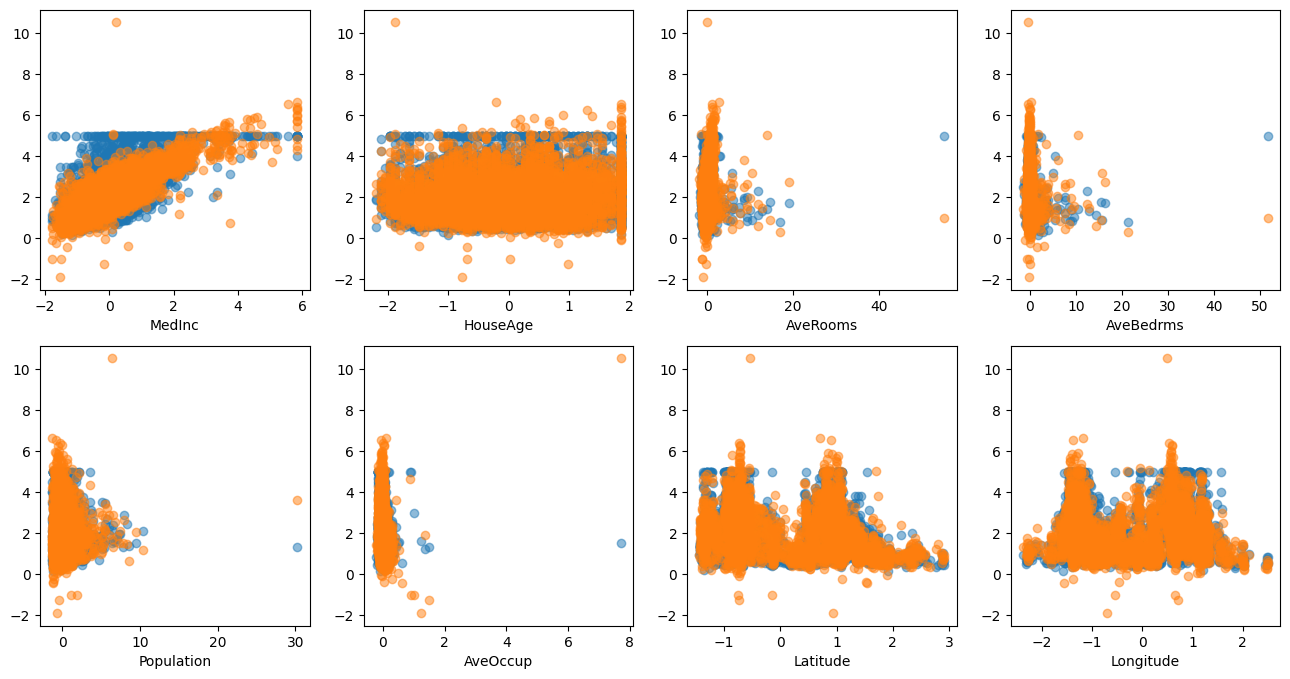

In [236]:
fig, plot = plt.subplots(2, 4, figsize=(16, 8))
plot = plot.ravel()
for i in range(8):
    plot[i].scatter(x_test[:, i], y_test, alpha=0.5, label="Actual")
    plot[i].scatter(x_test[:, i], y_predic_poly, alpha=0.5, label="Actual")
    plot[i].set_xlabel(x_features[i])